📈 Basic Metrics:
Mean Daily Return: 0.00046
Daily Volatility: 0.00967
Annual Return: 11.65%
Annual Volatility: 15.35%


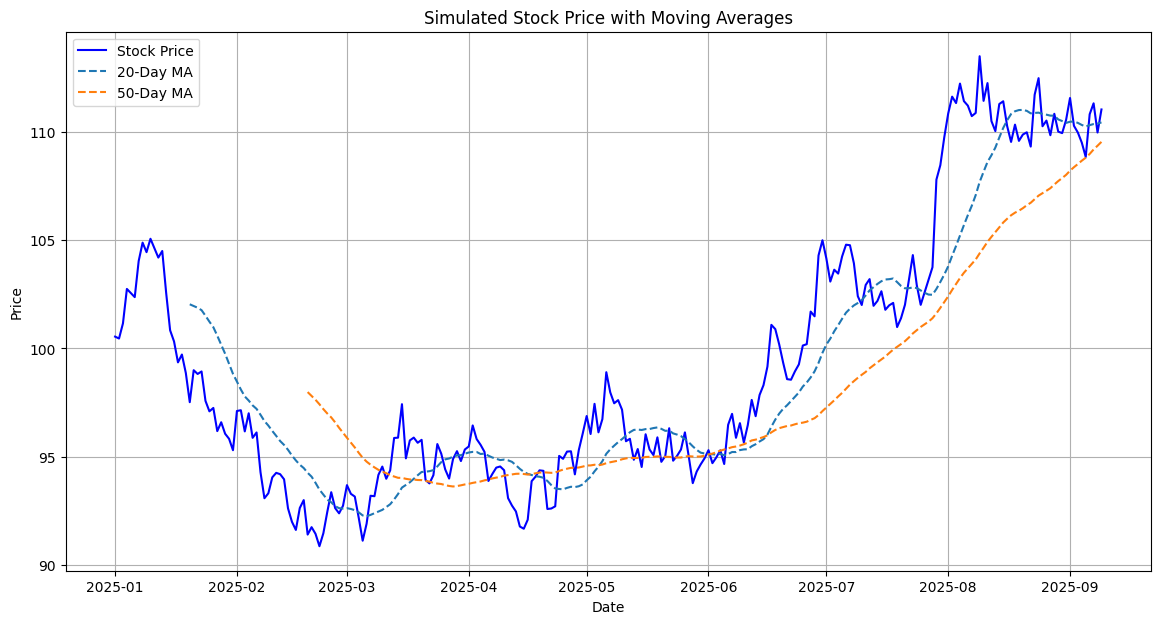

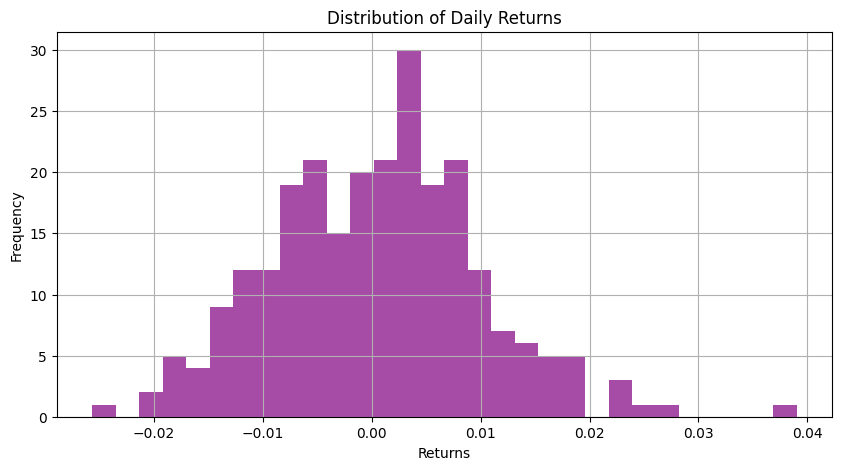

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1. SIMULATE STOCK PRICES
# -------------------------------
np.random.seed(42)

days = 252  # trading days in a year
initial_price = 100

# Daily returns (random walk)
mu = 0.0005        # average daily return
sigma = 0.01       # daily volatility

returns = np.random.normal(mu, sigma, days)

# Price series
prices = [initial_price]
for r in returns:
    prices.append(prices[-1] * (1 + r))

prices = prices[1:]

# Create DataFrame
dates = pd.date_range(start="2025-01-01", periods=days)
df = pd.DataFrame({
    "Date": dates,
    "Price": prices,
    "Returns": returns
})
df.set_index("Date", inplace=True)

# -------------------------------
# 2. CALCULATE METRICS
# -------------------------------
mean_return = df["Returns"].mean()
volatility = df["Returns"].std()
annual_return = mean_return * 252
annual_volatility = volatility * np.sqrt(252)

print("📈 Basic Metrics:")
print(f"Mean Daily Return: {mean_return:.5f}")
print(f"Daily Volatility: {volatility:.5f}")
print(f"Annual Return: {annual_return:.2%}")
print(f"Annual Volatility: {annual_volatility:.2%}")

# -------------------------------
# 3. MOVING AVERAGES
# -------------------------------
df["MA_20"] = df["Price"].rolling(window=20).mean()
df["MA_50"] = df["Price"].rolling(window=50).mean()

# -------------------------------
# 4. VISUALIZATION
# -------------------------------
plt.figure(figsize=(14, 7))

plt.plot(df.index, df["Price"], label="Stock Price", color="blue")
plt.plot(df.index, df["MA_20"], label="20-Day MA", linestyle="--")
plt.plot(df.index, df["MA_50"], label="50-Day MA", linestyle="--")

plt.title("Simulated Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

# -------------------------------
# 5. RETURNS DISTRIBUTION
# -------------------------------
plt.figure(figsize=(10, 5))
plt.hist(df["Returns"], bins=30, color="purple", alpha=0.7)

plt.title("Distribution of Daily Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()